In [49]:
import torch
import torch.nn as nn
import math

class CNNSubmodule(nn.Module):
    def __init__(self, in_channels=10): 
        super(CNNSubmodule, self).__init__()
    
        
        self.conv1 = nn.Conv1d(in_channels, in_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(in_channels)
        
       
        self.conv2 = nn.Conv1d(in_channels, in_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(in_channels)
        
        
        self.relu = nn.ReLU()

    def forward(self, x):
        # x shape: [Batch, 36, 10]
        x = x.transpose(1, 2) # [Batch, 10, 36]
        identity = x 
 
        out = self.conv1(x)
        out = self.bn1(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        out = out + identity 
        
        out = self.relu(out)
        
        return out.transpose(1, 2) # Retour en [Batch, 36, 10]
    





class ALPE(nn.Module):
    def __init__(self, d_model=10, max_len=36):
        super(ALPE, self).__init__()
        self.d_model = d_model
        
        #PE(t) = Initial Absolute Positional Encoding
        pe = torch.zeros(max_len, d_model)

        # cette liste sert a calculer les sinus et les cosinus car il faut un angle. Cet angle dépend du jour où on se trouve.
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0)) # Shape: [1, 36, d_model]

        #Conv1D Layer
        self.conv1d = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
        
        #ECA Module
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.eca_conv = nn.Conv1d(1, 1, kernel_size=3, padding=1, bias=False)
        self.sigmoid = nn.Sigmoid()



    def eca(self, x):
        y = self.avg_pool(x) 
        y = self.eca_conv(y.transpose(-1, -2)).transpose(-1, -2)
        y = self.sigmoid(y) 

        return x * y.expand_as(x)



    def forward(self, x, input2_mask):
        # x: [Batch, 36, 10] (Input 1 - Bandes spectrales)
        # input2_mask: [Batch, 36, 1] (Input 2 - Masque de nuages)
        
        b, t, c = x.size()
        
        #on recup la matrice de position initiale pour chaque echantillon
        pos_vector = self.pe[:, :t, :].clone().repeat(b, 1, 1) # [Batch, 36, 10]
        
        #si le jour est nuageux , on met tout son embedding à 0 pour que le modèle ne puisse pas s'appuyer dessus
        pos_vector = pos_vector * input2_mask 
        
        # format attendu par pythorch Shape: [Batch, 10, 36]
        pos_vector = pos_vector.transpose(1, 2)
        
        # le conv1d va apprendre à ajuster les embeddings positionnels en fonction des données d'entrée, en tenant compte des jours nuageux.
        pos_vector = self.conv1d(pos_vector)
    
        pos_vector = self.eca(pos_vector)
        
        
        return pos_vector.transpose(1, 2) # Sortie: [Batch, 36, 10]
    





class TransformerSubmodule(nn.Module):
    def __init__(self, d_model=10, nhead=2, dim_feedforward=64, use_alpe=False):
        super(TransformerSubmodule, self).__init__()
        self.use_alpe = use_alpe
        
        if self.use_alpe:    
            self.alpe = ALPE(d_model=d_model)
    
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)

    def forward(self, x, input2_mask=None):
        # x: Input spectral [Batch, 36, 10]
        # input2_mask: Le masque pour ALPE
        

        #stage 1 uniquement
        if self.use_alpe and input2_mask is not None:
                
                pos_info = self.alpe(x, input2_mask)
                x = x + pos_info
        
        
        # Ici se passent le Multi-Head Attention, Add & Norm, Feed Forward
        out = self.transformer_encoder(x)
        
        return out # Sortie [Batch, 36, 10]
#ici on va assembler les sous modules pour faire le MCTNet
class MCTNet(nn.Module):
    def __init__(self, num_classes):
        super(MCTNet, self).__init__()
        
        # STAGE 1 (d_model=10, avec ALPE)
        self.cnn1 = CNNSubmodule(in_channels=10)
        self.trans1 = TransformerSubmodule(d_model=10, use_alpe=True)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        # STAGE 2 (d_model=20, sans ALPE)
        self.cnn2 = CNNSubmodule(in_channels=20)
        self.trans2 = TransformerSubmodule(d_model=20, use_alpe=False)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        # STAGE 3 (d_model=40, sans ALPE)
        self.cnn3 = CNNSubmodule(in_channels=40)
        self.trans3 = TransformerSubmodule(d_model=40, use_alpe=False)
        self.global_pool = nn.AdaptiveMaxPool1d(1) # Pour arriver à 80*1 peu importe la taille restante
        
        # MLP Final
        self.mlp = nn.Sequential(
            nn.Linear(80, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, mask):
        #CTFusion 1
        c1 = self.cnn1(x)
        t1 = self.trans1(x, mask)
        x = torch.cat([c1, t1], dim=-1) # [B, 36, 20]
        x = self.pool1(x.transpose(1, 2)).transpose(1, 2) # [B, 18, 20]
        
        # CTFusion 2
        c2 = self.cnn2(x)
        t2 = self.trans2(x) 
        x = torch.cat([c2, t2], dim=-1) # [B, 18, 40]
        x = self.pool2(x.transpose(1, 2)).transpose(1, 2) # [B, 9, 40]
        
        # CTFusion 3
        c3 = self.cnn3(x)
        t3 = self.trans3(x)
        x = torch.cat([c3, t3], dim=-1) # [B, 9, 80]
        x = self.global_pool(x.transpose(1, 2)).squeeze(-1) # [B, 80]
        
        return self.mlp(x)

In [ ]:
import pandas as pd
df_cali = pd.read_csv('../data/california_preprocessed.csv')
df_ark = pd.read_csv('../data/arkansas_preprocessed.csv')

In [51]:
df_cali.head()

,d0_B2,d0_B3,d0_B4,d0_B5,d0_B6,d0_B7,d0_B8,d0_B8A,d0_B11,d0_B12,...,d35_B8A,d35_B11,d35_B12,clim_precip,clim_temp,soil_texture,topo_elevation,topo_slope,cropland,target_class
0,0.04820,0.06105,0.06470,0.09330,0.13855,0.15165,0.17355,0.17550,0.21355,0.15090,...,0.00000,0.00000,0.00000,0.397416,-0.651279,0.525297,-0.433458,-0.330163,76,4
1,0.06170,0.08805,0.10080,0.13435,0.19605,0.21765,0.23495,0.23375,0.27285,0.23035,...,0.00000,0.00000,0.00000,0.132386,1.235055,0.525297,-0.583178,-0.612763,36,2
2,0.04420,0.06350,0.10130,0.11880,0.13210,0.15020,0.17570,0.18160,0.24420,0.20890,...,0.41005,0.29705,0.24475,-1.015309,0.950606,0.525297,-0.266627,-0.443951,69,0
3,0.08615,0.10970,0.14635,0.16965,0.18835,0.20460,0.22510,0.23185,0.33110,0.25865,...,0.00000,0.00000,0.00000,-1.032278,1.098399,0.525297,-0.561790,-0.781662,36,2
4,0.24455,0.24090,0.25870,0.27515,0.27545,0.28775,0.30590,0.30050,0.38235,0.33175,...,0.00000,0.00000,0.00000,0.049402,1.259696,1.146951,-0.608845,-0.512391,36,2


In [52]:
import pandas as pd
import torch
import numpy as np

def analyze_df_quality(df, name="Dataset"):
    # 1. Définition de l'ordre des 10 bandes (B2 à B12)
    BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
    ordered_cols = []
    for i in range(36):
        for band in BANDS:
            ordered_cols.append(f'd{i}_{band}')
    
    # 2. Extraction et Reshape en [Batch, 36, 10]
    # On utilise .values pour convertir le DataFrame filtré en array numpy
    data_raw = df[ordered_cols].values
    x_spectral = torch.tensor(data_raw, dtype=torch.float32).view(-1, 36, 10)
    
    # 3. Calcul du nombre de jours avec au moins un 0
    days_with_zeros = (x_spectral == 0).any(dim=-1) # Shape: [Batch, 36]
    
    # Stats globales
    total_invalid_days = days_with_zeros.sum().item()
    total_possible_days = x_spectral.shape[0] * 36
    percentage = (total_invalid_days / total_possible_days) * 100
    
    # Analyse par échantillon
    avg_per_sample = days_with_zeros.sum(dim=1).float().mean().item()

    print(f"--- Analyse pour {name} ---")
    print(f"Shape finale : {x_spectral.shape}")
    print(f"Total jours avec au moins un 0 : {total_invalid_days} sur {total_possible_days}")
    print(f"Pourcentage de 'trous' : {percentage:.2f}%")
    print(f"Moyenne de jours impactés par échantillon : {avg_per_sample:.1f} / 36")
    print("-" * 30)
    
    return x_spectral, days_with_zeros

In [53]:
import torch

def prepare_mctnet_data(df):
    
    BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
    

    ordered_cols = []
    for i in range(36):
        for band in BANDS:
            ordered_cols.append(f'd{i}_{band}')
            
            
    x_spectral = torch.tensor(df[ordered_cols].values, dtype=torch.float32)
    x_spectral = x_spectral.view(-1, 36, 10) # [Batch, 36, 10]
    
    mask = (x_spectral > 0).all(dim=-1, keepdim=True).float() # [Batch, 36, 1]
    
   
    y = torch.tensor(df['target_class'].values, dtype=torch.long)
    
    return x_spectral, mask, y

In [54]:
import pandas as pd


mapping = {
    69: 0,   # Grapes
    3: 1,    # Rice
    36: 2,   # Alfalfa
    75: 3,   # Almonds
    76: 4,  # Pistachios
}


def map_classes(val):
    return mapping.get(val, 5) 

df_cali['target_class'] = df_cali['cropland'].apply(map_classes)


targets = {
    0: 2054, # Grapes
    1: 2037, # Rice
    2: 974,  # Alfalfa
    3: 783,  # Almonds
    4: 640,  # Pistachios
    5: 3512  # Others
}

sampled_dfs = []
for class_id, count in targets.items():
    sub_df = df_cali[df_cali['target_class'] == class_id]
    
    sampled_dfs.append(sub_df.sample(n=min(len(sub_df), count), random_state=42))

df_cali_final = pd.concat(sampled_dfs).sample(frac=1) 

In [55]:
df_cali_final['target_class'].value_counts()

target_class
5    3512
0    2054
1    2037
2     974
3     783
4     640
Name: count, dtype: int64

In [57]:
x_cali_final, holes_cali_final = analyze_df_quality(df_cali_final, name="California Final")

--- Analyse pour California Final ---
Shape finale : torch.Size([10000, 36, 10])
Total jours avec au moins un 0 : 13581 sur 360000
Pourcentage de 'trous' : 3.77%
Moyenne de jours impactés par échantillon : 1.4 / 36
------------------------------


In [33]:
x_cal, mask_cal, y_cal = prepare_mctnet_data(df_cali_final)

In [34]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader


x_train, x_temp, m_train, m_temp, y_train, y_temp = train_test_split(
    x_cal, mask_cal, y_cal, test_size=0.18, stratify=y_cal, random_state=42
)


x_val, x_test, m_val, m_test, y_val, y_test = train_test_split(
    x_temp, m_temp, y_temp, test_size=0.8, stratify=y_temp, random_state=42
)

train_loader = DataLoader(TensorDataset(x_train, m_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, m_val, y_val), batch_size=64)
test_loader = DataLoader(TensorDataset(x_test, m_test, y_test), batch_size=64)

print(f"Split terminé : Train={len(y_train)}, Val={len(y_val)}, Test={len(y_test)}")

Split terminé : Train=8200, Val=360, Test=1440


In [ ]:
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import copy 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 20

model = MCTNet(num_classes=6).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
criterion = torch.nn.CrossEntropyLoss()

#Variables pour stocker le meilleur ---
best_f1 = 0.0
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
    # --- PHASE TRAIN ---
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f"Époque {epoch+1}/{epochs}", unit="batch")
    
    for b_x, b_mask, b_y in pbar:
        b_x, b_mask, b_y = b_x.to(device), b_mask.to(device), b_y.to(device)
        optimizer.zero_grad()
        outputs = model(b_x, b_mask)
        loss = criterion(outputs, b_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # --- PHASE VALIDATION ---
    model.eval()
    val_preds, val_targets = [], []
    val_loss = 0
    with torch.no_grad():
        for b_x, b_mask, b_y in val_loader:
            b_x, b_mask, b_y = b_x.to(device), b_mask.to(device), b_y.to(device)
            outputs = model(b_x, b_mask)
            val_loss += criterion(outputs, b_y).item()
            _, predicted = torch.max(outputs, 1)
            val_preds.extend(predicted.cpu().numpy())
            val_targets.extend(b_y.cpu().numpy())

    precision, recall, f1, _ = precision_recall_fscore_support(
        val_targets, val_preds, average='macro', zero_division=0
    )
    val_acc = 100 * np.sum(np.array(val_preds) == np.array(val_targets)) / len(val_targets)

    print(f"\n[Validation] Loss: {val_loss/len(val_loader):.4f} | Acc: {val_acc:.2f}%")
    print(f"[Scores] Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}\n")

    #Sauvegarde si c'est le meilleur score ---
    if f1 > best_f1:
        best_f1 = f1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"⭐ Meilleur modèle mis à jour (F1: {best_f1:.4f})")

#Recharger le meilleur modèle dans 'model' à la fin ---
model.load_state_dict(best_model_state)
print(f"\n✅ Entraînement fini. 'model' contient maintenant les meilleurs poids (F1: {best_f1:.4f}).")

Époque 1/20:   0%|          | 0/129 [00:00<?, ?batch/s, loss=2.1076]

Époque 1/20: 100%|██████████| 129/129 [00:01<00:00, 84.07batch/s, loss=1.5231]



[Validation] Loss: 1.1544 | Acc: 61.94%
[Scores] Precision: 0.4980 | Recall: 0.4220 | F1-Score: 0.4088

⭐ Meilleur modèle mis à jour (F1: 0.4088)


Époque 2/20: 100%|██████████| 129/129 [00:01<00:00, 99.85batch/s, loss=0.8497]



[Validation] Loss: 0.8544 | Acc: 73.89%
[Scores] Precision: 0.5247 | Recall: 0.5728 | F1-Score: 0.5457

⭐ Meilleur modèle mis à jour (F1: 0.5457)


...


[Validation] Loss: 0.3263 | Acc: 89.72%
[Scores] Precision: 0.8989 | Recall: 0.8625 | F1-Score: 0.8756



Époque 19/20: 100%|██████████| 129/129 [00:01<00:00, 95.09batch/s, loss=0.7183]



[Validation] Loss: 0.3215 | Acc: 89.17%
[Scores] Precision: 0.8986 | Recall: 0.8626 | F1-Score: 0.8744



Époque 20/20: 100%|██████████| 129/129 [00:01<00:00, 95.01batch/s, loss=0.7406]



[Validation] Loss: 0.3267 | Acc: 89.44%
[Scores] Precision: 0.9005 | Recall: 0.8677 | F1-Score: 0.8771


✅ Entraînement fini. 'model' contient maintenant les meilleurs poids (F1: 0.8782).


In [36]:
torch.save(model.state_dict(), './models_cal/model_california.pth')
print("Modèle California sauvegardé")

Modèle California sauvegardé


=== California ===
OA    : 0.8806
Kappa : 0.8436
              precision    recall  f1-score   support

      Grapes       0.84      0.81      0.82       296
        Rice       1.00      0.99      0.99       293
     Alfalfa       0.96      0.97      0.97       140
     Almonds       0.77      0.62      0.69       113
  Pistachios       0.90      0.68      0.78        92
      Others       0.84      0.93      0.88       506

    accuracy                           0.88      1440
   macro avg       0.88      0.83      0.85      1440
weighted avg       0.88      0.88      0.88      1440



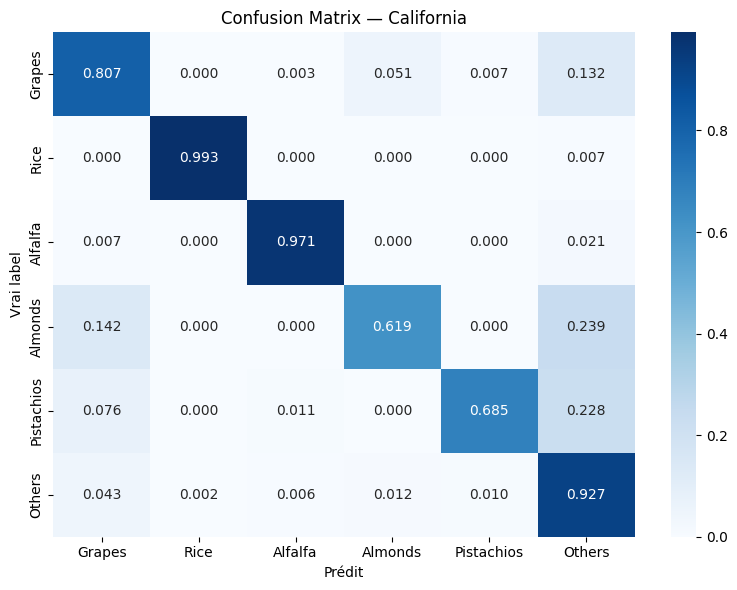

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_on_test(model, test_loader, class_names, title):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for b_x, b_mask, b_y in test_loader:
            b_x, b_mask, b_y = b_x.to(device), b_mask.to(device), b_y.to(device)
            outputs = model(b_x, b_mask)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(b_y.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    oa = (all_preds == all_labels).mean()
    kappa = cohen_kappa_score(all_labels, all_preds)
    
    print(f"=== {title} ===")
    print(f"OA    : {oa:.4f}")
    print(f"Kappa : {kappa:.4f}")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.3f', xticklabels=class_names,
                yticklabels=class_names, cmap='Blues')
    plt.title(f'Confusion Matrix — {title}')
    plt.ylabel('Vrai label')
    plt.xlabel('Prédit')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{title.lower()}.png', dpi=150)
    plt.show()

classes_ca = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
evaluate_on_test(model, test_loader, classes_ca, 'California')